In [108]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-02.parquet')

In [109]:
df.shape

(3577543, 20)

In [110]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
962438,1,2025-02-10 18:50:04,2025-02-10 18:54:28,1.0,0.40,1.0,N,113,113,2,5.8,5.75,0.5,0.00,0.0,1.0,13.05,2.5,0.0,0.75
474646,2,2025-02-05 20:35:41,2025-02-05 20:43:50,1.0,1.48,1.0,N,230,90,1,9.3,1.00,0.5,3.01,0.0,1.0,18.06,2.5,0.0,0.75
2036935,2,2025-02-21 18:39:19,2025-02-21 18:45:30,1.0,0.82,1.0,N,140,229,4,7.9,2.50,0.5,0.00,0.0,1.0,15.15,2.5,0.0,0.75


In [111]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          806937
trip_distance                 0
RatecodeID               806937
store_and_fwd_flag       806937
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     806937
Airport_fee              806937
cbd_congestion_fee            0
dtype: int64

In [112]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [113]:
df[df.duplicated()].shape

(0, 20)

In [114]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-02-01') | (df["tpep_pickup_datetime"] >= '2025-03-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
102,7,2025-02-01 00:01:10,2025-02-01 00:01:10,1.0,1.14,1.0,N,161,141,1,8.6,0.0,0.5,2.87,0.00,1.0,17.22,2.5,0.0,0.75
150,7,2025-02-01 00:32:48,2025-02-01 00:32:48,2.0,1.40,1.0,N,230,142,1,9.3,0.0,0.5,3.01,0.00,1.0,18.06,2.5,0.0,0.75
280,2,2025-01-31 23:59:03,2025-02-01 00:09:20,1.0,1.63,1.0,N,79,90,1,11.4,1.0,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75
335,2,2025-01-31 23:55:18,2025-02-01 00:04:08,1.0,1.08,1.0,N,148,209,1,10.0,1.0,0.5,3.15,0.00,1.0,18.90,2.5,0.0,0.75
475,2,2025-01-31 23:57:17,2025-02-01 00:05:39,1.0,1.12,1.0,N,125,148,1,10.0,1.0,0.5,0.00,0.00,1.0,15.75,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3496160,6,2025-02-26 14:02:54,2025-02-26 14:02:18,NaN,1.07,NaN,None,222,76,0,2.9,0.0,0.5,0.00,0.00,0.3,16.00,NaN,NaN,0.00
3496668,6,2025-02-26 15:02:39,2025-02-26 15:02:08,NaN,6.83,NaN,None,170,129,0,5.8,0.0,0.5,0.00,0.00,0.3,22.93,NaN,NaN,0.00
3496669,6,2025-02-26 15:02:37,2025-02-26 15:02:05,NaN,6.13,NaN,None,170,82,0,2.9,0.0,0.5,0.00,6.94,0.3,21.35,NaN,NaN,0.00
3512954,6,2025-02-27 07:02:54,2025-02-27 07:02:33,NaN,6.87,NaN,None,188,4,0,2.9,0.0,0.5,0.00,0.00,0.3,33.79,NaN,NaN,0.00


In [115]:
# проблемных строк 4529, удалим их 
df = df[~(mask_1 | mask_2 | mask_3)]

In [116]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [117]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1735,2,2025-02-01 00:21:49,2025-02-01 00:59:15,1.0,7.26,1.0,N,264,264,1,39.40,1.00,0.5,8.88,0.0,1.0,53.28,2.5,0.0,0.00
1841,1,2025-02-01 00:28:37,2025-02-01 00:31:32,1.0,0.80,1.0,N,264,264,1,5.80,4.25,0.5,2.30,0.0,1.0,13.85,2.5,0.0,0.75
1846,1,2025-02-01 00:14:24,2025-02-01 00:24:47,1.0,1.10,1.0,N,264,264,1,10.70,1.00,0.5,0.00,0.0,1.0,13.20,0.0,0.0,0.00
1879,1,2025-02-01 00:26:31,2025-02-01 00:36:52,2.0,1.70,1.0,N,264,264,1,11.40,4.25,0.5,3.40,0.0,1.0,20.55,2.5,0.0,0.75
2696,2,2025-02-01 00:08:05,2025-02-01 00:17:28,2.0,1.30,1.0,N,264,264,1,10.70,1.00,0.5,1.00,0.0,1.0,16.70,2.5,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3544067,1,2025-02-28 07:57:30,2025-02-28 08:06:56,NaN,1.70,NaN,None,264,140,0,10.70,0.00,0.5,1.47,0.0,1.0,16.17,NaN,NaN,0.00
3549217,2,2025-02-28 13:48:17,2025-02-28 14:03:30,NaN,0.00,NaN,None,264,264,0,-1.50,0.00,0.5,0.00,0.0,1.0,3.00,NaN,NaN,0.00
3555332,2,2025-02-28 17:27:00,2025-02-28 17:58:00,NaN,9.54,NaN,None,264,264,0,36.11,0.00,0.5,0.00,0.0,1.0,37.61,NaN,NaN,0.00
3562108,1,2025-02-28 19:17:18,2025-02-28 19:21:10,NaN,0.50,NaN,None,264,264,0,5.80,2.50,0.5,1.96,0.0,1.0,15.01,NaN,NaN,0.75


In [118]:
# записей с зоной 264 всего 7468, удаляю их
df = df[df["PULocationID"] != 264]

In [119]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 3577543-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 11997
осталось записей о поездке: 3565546
максимальная и минимальная даты в таблице: 2025-02-28 23:59:59 2025-02-01 00:00:00


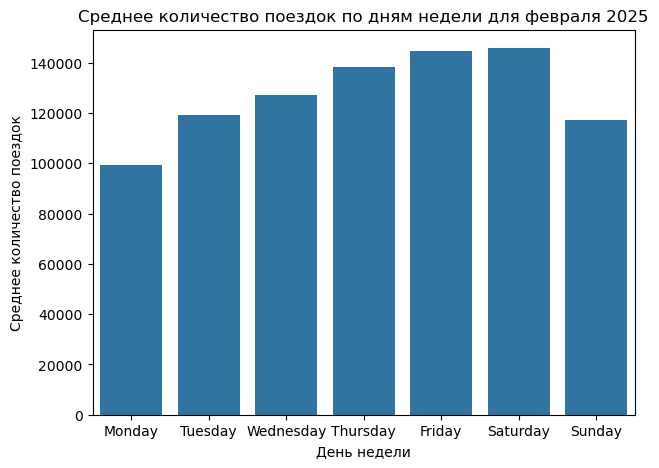

In [120]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для февраля 2025', xlabel='День недели', ylabel='Среднее количество поездок');

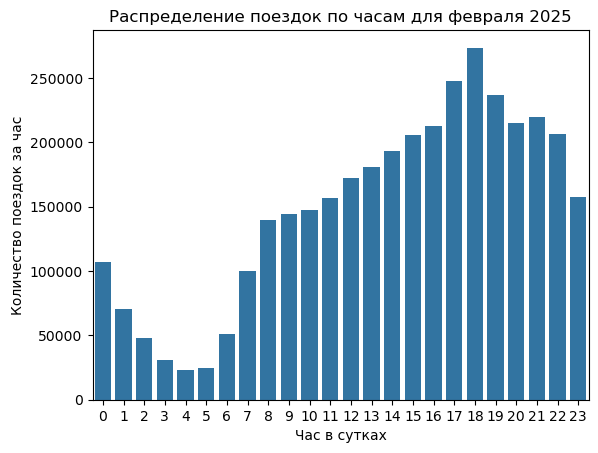

In [121]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для февраля 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

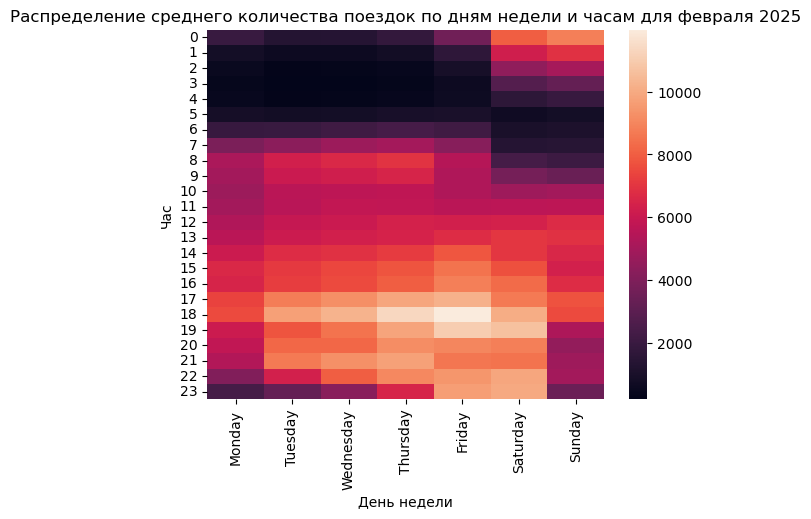

In [122]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для февраля 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [123]:
# Первые 2 графика распределения похожи на январские
# Хитмап для распределения 'день недели x час' тоже в целом похож, но имеет малые отклонения:
# заметно повышение спроса в пятницу и субботу с 19 до 23, пик активности - пятница в 18 ч.

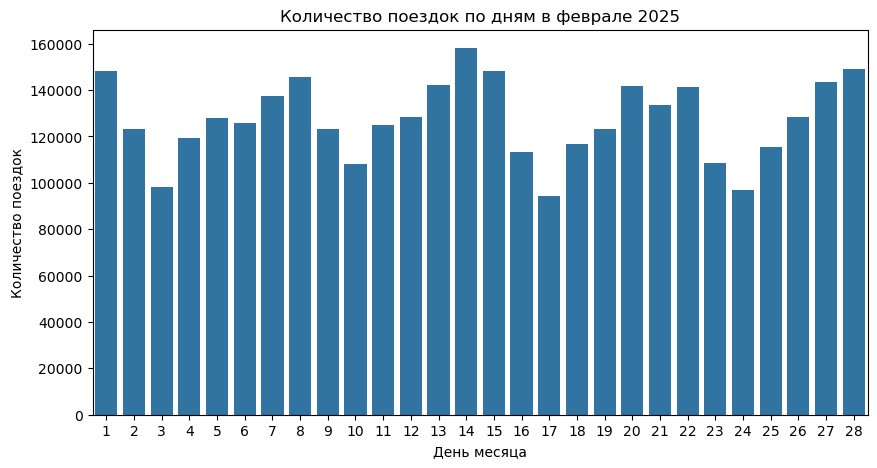

In [124]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в феврале 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Паттерн сохраняется: увеличение количества поездок на 5 (или 6) дней, потом спад на 2 (или 1) день.
# Особенно низкие значения наблюдаются по понедельникам: 3, 10, 17, 24 числа.
# Интересно, что 14 февраля в праздничный день заметен всплеск активности поездок.

In [125]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,305
EWR,314
Bronx,21455
Brooklyn,96784
Queens,291020
Manhattan,3154503


In [126]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-02-01,0,79,792
1,2025-02-01,0,161,114
2,2025-02-01,0,163,93
3,2025-02-01,0,186,141
4,2025-02-01,0,239,81
...,...,...,...,...
3344,2025-02-28,23,79,637
3345,2025-02-28,23,161,306
3346,2025-02-28,23,163,184
3347,2025-02-28,23,186,193


In [127]:
# В таблице должно быть 28 дней x 24 часа x 5 зон = 3360 записей,
# сейчас в таблице 3349 записей, пропуск строки значит, что в этот день, в этот час, в этом районе
# не было ни одной поездки на такси. Найдём такие записи и запишем для них 0 в pickups

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-02-01", "2025-02-28", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-02-01,0,79,792
1,2025-02-01,0,161,114
2,2025-02-01,0,163,93
3,2025-02-01,0,186,141
4,2025-02-01,0,239,81
...,...,...,...,...
3355,2025-02-28,23,79,637
3356,2025-02-28,23,161,306
3357,2025-02-28,23,163,184
3358,2025-02-28,23,186,193


In [128]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_02.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [129]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3360, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
